# Getting started: single-FOV SMLM fitting

This is the same worked example shown in the docs (`docs/getting-started.rst`) and the
project `README`, run end-to-end here against data that ships with the repository — no
external data or path edits needed.

It covers the four core `AnalysisPipeline` steps:

1. **Calibration** — load a pre-computed camera calibration (gain/offset/variance/read
   noise/relative QE maps).
2. **Fitting** — detect and fit single-molecule PSFs in a Bayer-mosaic camera stack.
3. **Loading localisations** — read the fitted results back from disk.
4. **Filtering & clustering** — apply quality filters and group repeat localisations of
   the same molecule into a per-molecule table.

The data is `test_tiffs/single_FOV_smlm/` — a small, synthetic single-dye (ATTO 647N)
acquisition simulated with a known ground truth (see its `README.md` for details) via
`pyS3M.simulation.pattern_source.simulate_acquisition` — the same backend
`notebooks/simulations/01_simulating_an_acquisition.ipynb` walks through directly.

## Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/analyses/ -> repo root
DATA_DIR = REPO_ROOT / "test_tiffs" / "single_FOV_smlm"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

plotter = PlottingBase.PublicationPlotter()

print(DATA_DIR, DATA_DIR.is_dir())
print(CALIBRATION_DIR, CALIBRATION_DIR.is_dir())

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/test_tiffs/single_FOV_smlm True
/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/Camera_Calibrations/Ximea_Camera True


## 1. Load calibration

Camera calibration (gain/offset/variance/read-noise/relative-QE maps) converts raw ADU
counts into calibrated photoelectron statistics that the fitter needs. `Camera_Calibrations/`
ships pre-computed maps for both supported cameras, so `load_calibration` is all that's
needed here.

If you have your own raw flat-field/dark frames instead, `AnalysisPipeline.calibrate(raw_dir)`
computes a fresh calibration from them (also available from the GUI's "CMOS Calibration"
tab, which documents the required raw-data folder layout) — not run here, since no raw
calibration exemplar dataset ships with the repo.

In [2]:
cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)
print("Calibration loaded:", pipe.gain_map.shape)

Calibration loaded: (1544, 2064)


## 2. Fit

`FittingConfig.peak_wavelength` should match the simulated/labelled dye's emission —
`test_tiffs/single_FOV_smlm/README.md` states the recommended value (0.685 µm) for this
fixture.

In [3]:
fc = FittingConfig(peak_wavelength=0.685, pfa=1e-3)
pipe.fit(DATA_DIR, mode="smlm", fitting_config=fc)

Detecting puncta:   0%|          | 0/100 [00:00<?, ?it/s]

[(             xc          yc       s_x       s_y      bg_B      bg_G      bg_R  \
  0     70.386833   72.565559  1.454214  1.565213  0.170001  0.349263  0.480736   
  1     70.456833   72.541489  1.527195  1.465962  0.617192  0.225953  0.156855   
  2     70.625473   29.780987  2.367439  1.588685  0.564102  0.277542  0.158355   
  3     70.426514   72.594048  1.537247  1.508724  0.249133  0.512080  0.238787   
  4    112.513611   13.028802  1.655658  1.478277  0.099136  0.546386  0.354478   
  ..          ...         ...       ...       ...       ...       ...       ...   
  105  115.990509   33.832569  1.481531  1.463819  0.098619  0.606900  0.294481   
  106   58.599922   73.779915  2.237742  0.794854  0.159589  0.412965  0.427446   
  107  126.063446  121.931702  1.518292  2.194894  0.142637  0.267491  0.589872   
  108   74.362030   35.789364  1.373767  1.133327  0.345997  0.285182  0.368821   
  109   51.372311  104.239410  1.385282  1.860708  0.164156  0.329341  0.506503   
  
 

## 3. Load localisations

In [4]:
locs = pipe.load_localisations(DATA_DIR)
print(f"{len(locs)} localisations")
locs.head()

110 localisations


,xc,yc,s_x,s_y,bg_B,bg_G,bg_R,A_B,A_G,A_R,...,A_R_err,spot_matched_filter_response,spot_background,spot_background_std,spot_mean_inner_intensity,spot_fraction_above_threshold,spot_n_pixels_above_threshold,spot_snr,photons,background_photons
0,70.386833,72.565559,1.454214,1.565213,0.170001,0.349263,0.480736,0.065954,0.212467,0.721579,...,0.000182,64.510666,33.880280,2.459595,41.515797,0.338843,41,3.104380,7107.985352,3.211376
1,70.456833,72.541489,1.527195,1.465962,0.617192,0.225953,0.156855,0.055455,0.215113,0.729432,...,0.000165,70.069725,33.959991,2.394877,42.606468,0.347107,42,3.610405,8265.753906,2.886002
2,70.625473,29.780987,2.367439,1.588685,0.564102,0.277542,0.158355,0.021101,0.498446,0.480453,...,0.010211,34.880398,33.664169,2.376456,33.827557,0.033058,4,0.068752,263.182800,2.564260
3,70.426514,72.594048,1.537247,1.508724,0.249133,0.512080,0.238787,0.070521,0.208998,0.720480,...,0.000150,68.643166,34.094025,2.331935,42.453945,0.371901,45,3.584971,8018.996094,3.786502
4,112.513611,13.028802,1.655658,1.478277,0.099136,0.546386,0.354478,0.309270,0.161381,0.529349,...,0.009350,34.885353,33.378036,1.979148,33.540352,0.049587,6,0.082013,247.343033,1.546766


## 4. Filter & cluster

`filter_and_cluster` applies quality-filtering thresholds (`FilteringCriteria`) and then
clusters repeat localisations of the same molecule (`ClusteringConfig`, HDBSCAN by
default), returning two tables:

- `sm_db` — one row per **molecule** (clustered, higher-SNR average).
- `sf_db` — one row per **localisation** (single-frame, pre-averaging), carrying a
  `molecular_index` column linking it back to its parent row in `sm_db`.

**`min_cluster_size` needs to match the imaging modality.** `single_FOV_smlm` is a
**STORM**-style fixture: each labelled site photobleaches permanently after a handful of
on/off cycles (5, here), so no single molecule is ever seen more than a few times. HDBSCAN's
default `min_cluster_size=10` is tuned for **PAINT**-style repeat-visit blinking instead
(continuously-exchanging transient probes revisit the same site many times — see
`04_clustering_and_quality_filtering.ipynb`, which uses a PAINT fixture and the default
cluster size). Passing the PAINT-sized default here would find no clusters at all — every
localisation is legitimately clustered into groups of one to a few, so `min_cluster_size`
must be small enough to allow that.

In [5]:
from pyS3M.clustering import ClusteringConfig

cc = ClusteringConfig(min_cluster_size=2)
sm_db, sf_db = pipe.filter_and_cluster(locs, clustering_config=cc)
print(f"{len(sm_db)} molecules from {len(sf_db)} quality-filtered localisations")

8 molecules from 29 quality-filtered localisations


## Render

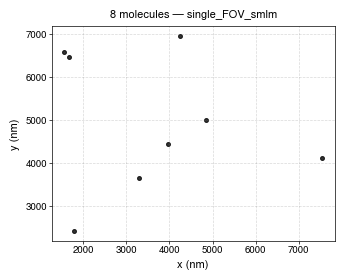

In [6]:
fig, ax = plotter.create_figure()
pixel_size_nm = pipe.pixel_size * 1000.0
plotter.scatter_plot(ax, sm_db["xc"] * pixel_size_nm, sm_db["yc"] * pixel_size_nm,
                      xlabel="x (nm)", ylabel="y (nm)", size=8, alpha=0.8)
ax.set_aspect("equal")
ax.set_title(f"{len(sm_db)} molecules — single_FOV_smlm")
plt.show()

## Next steps

- `02_multi_fov_fitting.ipynb` — fitting several fields of view in one folder.
- `03_drift_correction.ipynb` — AIM drift correction, including a real segmentation/`roi_r`
  trade-off this fixture is specifically built to demonstrate.
- `04_clustering_and_quality_filtering.ipynb` — a closer look at `FilteringCriteria` and
  `ClusteringConfig`.
- `05_channel_unmixing.ipynb` — separating spectrally-distinct dye populations.
- `06_nile_red_pixelated_wavelength_fit.ipynb` — Nile Red environment-sensing analysis.
- `07_frc.ipynb` — estimating spatial resolution (Fourier Ring Correlation).
- `../simulations/` — how the `test_tiffs/` fixtures used throughout these notebooks were
  generated, and how to simulate your own.